In [2]:
!pip install torch torchvision torchaudio pandas numpy matplotlib scikit-learn requests

  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.1-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached certifi-2026.1.4-py3-none-any.whl.metadata (2.5 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached markupsafe-3.0.3-cp312-cp312-win_amd64.whl.metadata (2.8 kB)
   ---------------------------------------- 0.0/110.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/110.9 MB ? eta -:--:--
   ---------------------------------------- 0.8/110.9 MB 2.4 MB/s eta 0:00:47
   ---------------------------------------- 1.3/110.9 MB 2.3

In [2]:
import requests
import pandas as pd
import time

class BinanceDataLoader:
    def __init__(self):
        self.url = "https://fapi.binance.com/fapi/v1/klines"

    def fetch_historical_data(
        self,
        symbol="BTCUSDT",
        interval="1d",
        start_str=None,
        limit=5000
    ):
        all_data = []
        start_time = None

        if start_str:
            start_time = int(pd.Timestamp(start_str).timestamp() * 1000)

        while len(all_data) < limit:
            fetch_limit = min(1500, limit - len(all_data))

            params = {
                "symbol": symbol,
                "interval": interval,
                "limit": fetch_limit
            }
            if start_time:
                params["startTime"] = start_time

            response = requests.get(self.url, params=params)
            data = response.json()

            if not isinstance(data, list) or len(data) == 0:
                break

            df_batch = pd.DataFrame(data, columns=[
                "timestamp", "open", "high", "low", "close", "volume",
                "close_time", "quote_asset_volume", "trades",
                "taker_buy_base", "taker_buy_quote", "ignore"
            ])

            df_batch[["open", "high", "low", "close", "volume"]] = \
                df_batch[["open", "high", "low", "close", "volume"]].astype(float)

            all_data.append(df_batch)

            start_time = int(df_batch.iloc[-1]["timestamp"]) + 1

            if len(df_batch) < fetch_limit:
                break

            time.sleep(0.2)

        if not all_data:
            return pd.DataFrame()

        df = pd.concat(all_data, ignore_index=True)
        df["datetime"] = pd.to_datetime(df["timestamp"], unit="ms")
        df.set_index("datetime", inplace=True)

        return df


In [34]:
loader = BinanceDataLoader()

df = loader.fetch_historical_data(
    symbol="BTCUSDT",
    interval="1d",
    start_str="2021-01-01",
    limit=1000
)

df.head()


,timestamp,open,high,low,close,volume,close_time,quote_asset_volume,trades,taker_buy_base,taker_buy_quote,ignore
datetime,,,,,,,,,,,,
2021-01-01,1609459200000,28948.19,29668.86,28627.12,29337.16,210716.398,1609545599999,6157505024.08511,1511793,101247.902,2960175587.62208,0
2021-01-02,1609545600000,29337.15,33480.00,28958.24,32199.91,545541.080,1609631999999,17122938614.70610,3514545,273388.463,8578964529.70894,0
2021-01-03,1609632000000,32198.41,34832.25,32000.02,33054.53,487486.989,1609718399999,16389111411.52760,3325307,238761.657,8029365512.72767,0
2021-01-04,1609718400000,33053.93,33653.56,27800.00,32031.07,506128.023,1609804799999,15879195836.25302,3470951,242947.199,7626162910.40660,0
2021-01-05,1609804800000,32029.55,34500.00,29900.00,33999.52,433720.833,1609891199999,13959353458.55198,3077140,214417.082,6904989558.83828,0


In [21]:
import pandas as pd

df = pd.read_csv("bitcoin_sentiments_21_24.csv")
df.head()

,Date,Short Description,Accurate Sentiments
0,2021-11-05 04:42:00,Bitcoin price is consolidating near the USD 62...,0.998558
1,2021-11-05 08:15:00,Congress could finally approve or reject the m...,0.000000
2,2021-11-05 10:24:00,Bitcoin increasingly becoming a political inst...,0.000000
3,2021-11-05 16:58:00,There is still potential for the price of bitc...,0.999458
4,2021-11-05 21:00:00,'Several companies' are looking to Latin Ameri...,0.000000


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
import matplotlib.pyplot as plt

# --- 1. XỬ LÝ DỮ LIỆU SENTIMENT ---
# Giả sử file của bạn là 'sentiment.csv'
# Bạn cần thay thế dòng này bằng code đọc file thực tế của bạn
# df_sentiment = pd.read_csv('sentiment.csv')

# (Dữ liệu giả lập demo dựa trên ảnh bạn gửi để code chạy được ngay)
data_sentiment = {
    'Date': ['2021-11-05 04:42:00', '2021-11-05 08:15:00', '2021-11-05 10:24:00',
             '2021-11-05 16:58:00', '2021-11-05 21:00:00', '2021-11-06 09:00:00'],
    'Accurate Sentiments': [0.998558, 0.000000, 0.000000, 0.999458, 0.000000, -0.5]
}
df_sentiment = pd.DataFrame(data_sentiment)

# Chuyển đổi cột Date sang datetime
df_sentiment['Date'] = pd.to_datetime(df_sentiment['Date'])

# Set index là Date để có thể resample
df_sentiment.set_index('Date', inplace=True)

# QUAN TRỌNG: Gom nhóm tin tức theo khung 1 giờ (1H)
# Nếu trong 1 giờ có nhiều tin, ta tính trung bình cộng sentiment
df_sentiment_resampled = df_sentiment['Accurate Sentiments'].resample('1h').mean()

# --- 2. TẢI DỮ LIỆU GIÁ TỪ BINANCE ---
# Sử dụng class BinanceDataLoader bạn đã cung cấp
loader = BinanceDataLoader()

# Xác định thời gian bắt đầu và kết thúc dựa trên dữ liệu sentiment để tải cho khớp
start_date = df_sentiment.index.min().strftime('%Y-%m-%d')

# Tải dữ liệu nến 1 GIỜ (1h) để khớp với sentiment đã gom nhóm
# Lưu ý: Interval nên nhỏ (1h hoặc 15m) để mô hình học được tác động ngắn hạn
df_price = loader.fetch_historical_data(
    symbol="BTCUSDT",
    interval="1h",  # Chỉnh thành 1h thay vì 1d
    start_str=start_date,
    limit=1000 # Tải đủ dữ liệu bao phủ khoảng thời gian sentiment
)

# --- 3. GHÉP DỮ LIỆU (MERGE) ---
# Merge dữ liệu giá và sentiment dựa trên index (thời gian)
# use left_index=True, right_index=True
df_merged = df_price.join(df_sentiment_resampled, how='left')

# Đổi tên cột sentiment cho dễ gọi
df_merged.rename(columns={'Accurate Sentiments': 'sentiment'}, inplace=True)

# Xử lý các giờ không có tin tức (NaN)
# Cách 1: Điền 0 (Trung lập) - Đơn giản nhất
df_merged['sentiment'] = df_merged['sentiment'].fillna(0)

# Cách 2: Forward Fill (Giữ cảm xúc cũ cho đến khi có tin mới) - Thường tốt hơn
# df_merged['sentiment'] = df_merged['sentiment'].fillna(method='ffill').fillna(0)

# Loại bỏ các dòng thiếu dữ liệu giá (nếu có)
df_merged.dropna(subset=['close'], inplace=True)

print("Dữ liệu sau khi ghép:")
print(df_merged[['close', 'volume', 'sentiment']].head())

Dữ liệu sau khi ghép:
                        close    volume  sentiment
datetime                                          
2021-11-05 00:00:00  60929.21  5936.305   0.000000
2021-11-05 01:00:00  61838.58  7272.239   0.000000
2021-11-05 02:00:00  61660.97  6092.052   0.000000
2021-11-05 03:00:00  62243.11  9352.456   0.000000
2021-11-05 04:00:00  62136.61  4593.170   0.998558


In [4]:
df_merged.head(20)

,timestamp,open,high,low,close,volume,close_time,quote_asset_volume,trades,taker_buy_base,taker_buy_quote,ignore,sentiment
datetime,,,,,,,,,,,,,
2021-11-05 00:00:00,1636070400000,61433.90,61548.89,60863.62,60929.21,5936.305,1636073999999,363432226.34660,73912,2533.829,155183619.27776,0,0.000000
2021-11-05 01:00:00,1636074000000,60929.21,61900.00,60900.09,61838.58,7272.239,1636077599999,446795833.49352,85983,4305.236,264523335.51392,0,0.000000
2021-11-05 02:00:00,1636077600000,61838.58,61955.05,61660.97,61660.97,6092.052,1636081199999,376635295.32156,73106,2776.021,171637915.25961,0,0.000000
2021-11-05 03:00:00,1636081200000,61660.97,62389.31,61660.97,62243.11,9352.456,1636084799999,581264501.82712,106070,5223.087,324574879.98325,0,0.000000
2021-11-05 04:00:00,1636084800000,62243.10,62357.00,62118.16,62136.61,4593.170,1636088399999,285773489.57712,67283,2132.298,132683600.94253,0,0.998558
2021-11-05 05:00:00,1636088400000,62136.61,62230.00,61914.91,62223.25,3864.537,1636091999999,239874718.71242,61098,1692.301,105065794.39887,0,0.000000
2021-11-05 06:00:00,1636092000000,62223.25,62671.48,62173.73,62217.14,7596.191,1636095599999,474137343.98601,104805,3784.590,236249929.05320,0,0.000000
2021-11-05 07:00:00,1636095600000,62217.14,62533.62,62151.10,62183.90,4726.346,1636099199999,294575563.30798,70828,2412.955,150386422.67449,0,0.000000
2021-11-05 08:00:00,1636099200000,62183.91,62284.48,62013.98,62263.89,5327.292,1636102799999,331008012.19035,69898,2784.804,173042666.79192,0,0.000000


In [24]:
# --- 4. CHUẨN BÓA DỮ LIỆU (SCALING) ---
# LSTM rất nhạy cảm với scale, cần đưa về khoảng 0-1
scaler = MinMaxScaler(feature_range=(0, 1))

# Chọn các cột features
feature_cols = ['open', 'high', 'low', 'close', 'volume', 'sentiment']
data_scaled = scaler.fit_transform(df_merged[feature_cols])

# --- 5. TẠO WINDOW (SLIDING WINDOW) ---
def create_sequences(data, window_size=60):
    X, y = [], []
    # data ở đây đã bao gồm cả price và sentiment
    # Cột 'close' là cột thứ 3 (index 3) trong feature_cols=['open', 'high', 'low', 'close',...]
    target_col_index = 3 
    
    for i in range(window_size, len(data)):
        # Lấy 60 dòng quá khứ làm Input
        X.append(data[i-window_size:i, :]) 
        # Lấy giá Close của dòng hiện tại làm Output (dự đoán bước tiếp theo)
        y.append(data[i, target_col_index])
        
    return np.array(X), np.array(y)

WINDOW_SIZE = 24 # Dùng 24 giờ quá khứ để dự đoán giờ tiếp theo
X, y = create_sequences(data_scaled, window_size=WINDOW_SIZE)

# Chia Train/Test
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Kích thước X_train: {X_train.shape}") # (Samples, 24, 6)
print(f"Kích thước y_train: {y_train.shape}")

Kích thước X_train: (29421, 24, 6)
Kích thước y_train: (29421,)


Using device: cpu
Bắt đầu huấn luyện...
Epoch [10/10], Loss: 0.000023

=== KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ===
MSE: 986298.1905
RMSE: 993.1255


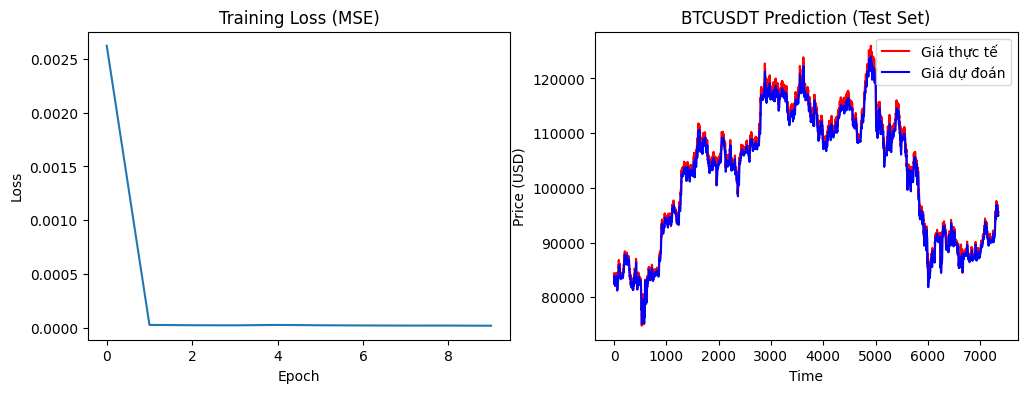

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import math

# --- CẤU HÌNH THIẾT BỊ (GPU/CPU) ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ==========================================
# 1. ĐỊNH NGHĨA KIẾN TRÚC MÔ HÌNH (Theo mục 6.7.1)
# ==========================================
class PricePredictor(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size=1, model_type="LSTM"):
        super(PricePredictor, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.model_type = model_type

        # Chọn loại mô hình RNN: LSTM hoặc GRU
        if model_type == "LSTM":
            self.rnn = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        elif model_type == "GRU":
            self.rnn = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        else:
            raise ValueError("Model type must be 'LSTM' or 'GRU'")
        
        # Lớp Feed Forward (Linear) để ánh xạ ra kết quả cuối cùng
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: (batch_size, sequence_length, input_size)
        
        # Khởi tạo hidden state (và cell state cho LSTM)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        
        if self.model_type == "LSTM":
            c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
            out, _ = self.rnn(x, (h0, c0))
        else:
            out, _ = self.rnn(x, h0)
        
        # Lấy output tại bước thời gian cuối cùng (Many-to-One)
        # out shape: (batch_size, sequence_length, hidden_size)
        out = out[:, -1, :] 
        
        # Đưa qua lớp Feed Forward
        out = self.fc(out)
        return out

# ==========================================
# 2. CHUẨN BỊ DỮ LIỆU (WINDOWING)
# ==========================================
def prepare_data(df, window_size=60, train_split=0.8):
    # Chọn các features (Đảm bảo thứ tự cột thống nhất)
    # Ví dụ: Open, High, Low, Close, Volume, Sentiment
    features = ['open', 'high', 'low', 'close', 'volume', 'sentiment']
    data = df[features].values
    
    # Chuẩn hóa Min-Max (0-1) - Quan trọng cho LSTM/GRU
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)
    
    X, y = [], []
    # Index cột 'close' để làm target (giả sử 'close' nằm ở vị trí 3)
    target_idx = features.index('close')
    
    for i in range(window_size, len(scaled_data)):
        X.append(scaled_data[i-window_size:i, :]) # Lấy chuỗi quá khứ
        y.append(scaled_data[i, target_idx])       # Lấy giá close tương lai
        
    X, y = np.array(X), np.array(y)
    
    # Chuyển sang Tensor PyTorch
    X = torch.FloatTensor(X)
    y = torch.FloatTensor(y).view(-1, 1) # Reshape thành (N, 1)
    
    # Chia Train/Test
    split_idx = int(len(X) * train_split)
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    
    return X_train, y_train, X_test, y_test, scaler

# ==========================================
# 3. HUẤN LUYỆN & ĐÁNH GIÁ
# ==========================================
def train_model(model, train_loader, criterion, optimizer, num_epochs=50):
    model.train() # Chế độ huấn luyện
    loss_history = []
    
    for epoch in range(num_epochs):
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            # Forward pass
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch) # Tính MSE Loss
            
            # Backward pass & Optimization
            optimizer.zero_grad() # Xóa gradient cũ
            loss.backward()       # Lan truyền ngược
            optimizer.step()      # Cập nhật trọng số (Adam)
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_loss)
        if (epoch+1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}')
            
    return loss_history

def evaluate_model(model, X_test, y_test, scaler):
    model.eval() # Chế độ đánh giá (tắt dropout, batchnorm)
    with torch.no_grad():
        X_test = X_test.to(device)
        predictions = model(X_test).cpu().numpy()
        y_test = y_test.numpy()
        
    # Inverse transform để đưa về giá thực tế (USD)
    # Vì scaler fit với 6 cột, ta cần tạo dummy array để inverse cột close
    dummy_pred = np.zeros((len(predictions), 6)) # 6 là số features
    dummy_true = np.zeros((len(y_test), 6))
    
    # Giả sử Close nằm ở cột index 3 (như hàm prepare_data)
    target_idx = 3 
    dummy_pred[:, target_idx] = predictions.flatten()
    dummy_true[:, target_idx] = y_test.flatten()
    
    real_pred = scaler.inverse_transform(dummy_pred)[:, target_idx]
    real_true = scaler.inverse_transform(dummy_true)[:, target_idx]
    
    # Tính MSE và RMSE (Theo mục 6.7.2)
    mse = mean_squared_error(real_true, real_pred)
    rmse = math.sqrt(mse)
    
    print(f"\n=== KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ===")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    
    return real_true, real_pred

# ==========================================
# 4. CHẠY CHƯƠNG TRÌNH (MAIN)
# ==========================================
# Giả sử df_merged là DataFrame bạn đã tạo ở bước trước
# Nếu chưa có, hãy chạy code phần Data Loader trước để có df_merged
if 'df_merged' in locals() and not df_merged.empty:

    # 1. Chuẩn bị dữ liệu
    WINDOW_SIZE = 60 # Dùng 60 nến quá khứ
    BATCH_SIZE = 64
    
    X_train, y_train, X_test, y_test, scaler = prepare_data(df_merged, window_size=WINDOW_SIZE)
    
    # Tạo DataLoader cho training
    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    
    # 2. Khởi tạo mô hình
    input_dim = 6    # Open, High, Low, Close, Volume, Sentiment
    hidden_dim = 64  # Số nơ-ron trong lớp ẩn
    num_layers = 2   # Số lớp chồng nhau (Stacked LSTM)
    output_dim = 1   # Dự đoán 1 giá trị (Close)
    
    # Chọn 'LSTM' hoặc 'GRU' tại đây
    model = PricePredictor(input_dim, hidden_dim, num_layers, output_dim, model_type="LSTM").to(device)
    
    # 3. Định nghĩa Loss và Optimizer (Theo tài liệu: MSE + Adam)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # 4. Huấn luyện
    print("Bắt đầu huấn luyện...")
    loss_history = train_model(model, train_loader, criterion, optimizer, num_epochs=10)
    
    # 5. Đánh giá và Vẽ biểu đồ
    real_true, real_pred = evaluate_model(model, X_test, y_test, scaler)
    
    # Vẽ biểu đồ Loss
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(loss_history)
    plt.title('Training Loss (MSE)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    
    # Vẽ biểu đồ Dự đoán vs Thực tế (Giống hình trong tài liệu trang 47)
    plt.subplot(1, 2, 2)
    plt.plot(real_true, color='red', label='Giá thực tế')
    plt.plot(real_pred, color='blue', label='Giá dự đoán')
    plt.title('BTCUSDT Prediction (Test Set)')
    plt.xlabel('Time')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.show()

else:
    print("Vui lòng đảm bảo biến 'df_merged' đã được tạo từ bước tải dữ liệu trước đó.")

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np
import requests
import time
import math
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# Cấu hình thiết bị (GPU nếu có)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang chạy trên thiết bị: {DEVICE}")

# Cấu hình hiển thị biểu đồ
plt.style.use('seaborn-v0_8')

Đang chạy trên thiết bị: cpu


In [6]:
class BinanceDataLoader:
    def __init__(self):
        self.base_url = "https://fapi.binance.com/fapi/v1/klines"

    def fetch_data(self, symbol="BTCUSDT", interval="1h", start_str=None, end_str=None):
        """
        Tải dữ liệu lịch sử từ Binance Futures
        start_str: Dạng 'YYYY-MM-DD'
        """
        all_data = []
        params = {"symbol": symbol, "interval": interval, "limit": 1500}
        
        if start_str:
            start_ts = int(pd.Timestamp(start_str).timestamp() * 1000)
            params["startTime"] = start_ts
            
        end_ts = int(pd.Timestamp(end_str).timestamp() * 1000) if end_str else int(time.time() * 1000)

        print(f"Đang tải dữ liệu {symbol} từ {start_str}...", end=" ")
        
        while True:
            try:
                response = requests.get(self.base_url, params=params)
                data = response.json()
                
                if not data or not isinstance(data, list):
                    break
                
                df = pd.DataFrame(data, columns=[
                    "timestamp", "open", "high", "low", "close", "volume",
                    "close_time", "q_vol", "trades", "taker_base", "taker_quote", "ignore"
                ])
                
                # Convert kiểu dữ liệu
                cols = ["open", "high", "low", "close", "volume"]
                df[cols] = df[cols].astype(float)
                df["datetime"] = pd.to_datetime(df["timestamp"], unit="ms")
                
                all_data.append(df)
                
                # Kiểm tra điều kiện dừng
                last_ts = df.iloc[-1]["timestamp"]
                if last_ts >= end_ts or len(df) < 100:
                    break
                    
                # Cập nhật startTime cho batch tiếp theo
                params["startTime"] = int(last_ts) + 1
                time.sleep(0.1) # Tránh bị chặn IP
                
            except Exception as e:
                print(f"\nLỗi tải dữ liệu: {e}")
                break

        if not all_data:
            return pd.DataFrame()
            
        final_df = pd.concat(all_data, ignore_index=True)
        final_df = final_df.set_index("datetime").sort_index()
        
        # Cắt đúng khoảng thời gian yêu cầu
        if end_str:
            final_df = final_df[:end_str]
            
        print(f"-> Hoàn tất: {len(final_df)} nến.")
        return final_df

def load_and_process_sentiment(csv_path):
    """Đọc file sentiment và gom nhóm theo giờ"""
    print(f"Đang xử lý file sentiment: {csv_path}...")
    df = pd.read_csv(csv_path)
    
    # 1. Chuyển đổi cột Date
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    df.sort_index(inplace=True)
    
    # 2. Resample về khung 1 Giờ (1H)
    # Vì một giờ có thể có nhiều tin -> Lấy trung bình cộng sentiment
    df_resampled = df['Accurate Sentiments'].resample('1h').mean()
    
    # Đổi tên thành Series cho dễ merge
    df_resampled.name = 'sentiment'
    
    return df_resampled

In [7]:
def prepare_dataset(sentiment_file, symbol="BTCUSDT", window_size=60):
    # --- 1. Load Sentiment ---
    series_sentiment = load_and_process_sentiment(sentiment_file)
    
    # Lấy ngày bắt đầu và kết thúc từ file sentiment để tải giá cho khớp
    start_date = series_sentiment.index.min().strftime('%Y-%m-%d')
    end_date = series_sentiment.index.max().strftime('%Y-%m-%d')
    
    # --- 2. Load Price Data from Binance ---
    loader = BinanceDataLoader()
    df_price = loader.fetch_data(symbol, interval="1h", start_str=start_date, end_str=end_date)
    
    # --- 3. Merge Data ---
    # Join sentiment vào bảng giá dựa trên index (datetime)
    df_merged = df_price.join(series_sentiment, how='left')
    
    # Xử lý Missing Value
    # Nếu giờ đó không có tin tức -> Fill 0 (Trung lập) hoặc dùng ffill (giữ tin cũ)
    # Ở đây ta dùng fill 0 để an toàn
    df_merged['sentiment'] = df_merged['sentiment'].fillna(0)
    
    # Loại bỏ các dòng thiếu dữ liệu giá (nếu có)
    df_merged.dropna(subset=['close'], inplace=True)
    
    print(f"Dữ liệu sau khi merge: {df_merged.shape}")
    
    # --- 4. Scaling (Chuẩn hóa) ---
    feature_cols = ['open', 'high', 'low', 'close', 'volume', 'sentiment']
    target_col = 'close' # Mục tiêu dự đoán

    # Tách Scaler riêng cho X và y để dễ inverse sau này
    scaler_X = MinMaxScaler(feature_range=(0, 1))
    scaler_y = MinMaxScaler(feature_range=(0, 1))

    scaled_data = scaler_X.fit_transform(df_merged[feature_cols])
    
    # Fit riêng cột close cho scaler_y
    scaler_y.fit(df_merged[[target_col]])

    # --- 5. Tạo Sliding Window ---
    X, y = [], []
    # Cột 'close' nằm ở vị trí thứ 3 trong feature_cols
    target_idx = feature_cols.index(target_col) 
    
    for i in range(window_size, len(scaled_data)):
        # Input: window_size dòng quá khứ
        X.append(scaled_data[i-window_size:i, :]) 
        # Output: Giá close tại thời điểm hiện tại
        y.append(scaled_data[i, target_idx])
        
    X = torch.FloatTensor(np.array(X))
    y = torch.FloatTensor(np.array(y)).unsqueeze(1) # Shape (N, 1)
    
    return X, y, scaler_y, df_merged.index[window_size:]

# === THỰC THI PIPELINE ===
FILE_NAME = 'bitcoin_sentiments_21_24.csv' # Tên file bạn đã upload
WINDOW_SIZE = 24 # Dùng 24h quá khứ để dự đoán

# Chạy hàm
try:
    X, y, scaler_y, time_index = prepare_dataset(FILE_NAME, window_size=WINDOW_SIZE)
    
    # Chia Train/Test (80/20)
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    test_times = time_index[split:]

    print(f"\nKích thước tập Train: {X_train.shape}")
    print(f"Kích thước tập Test: {X_test.shape}")
    
except FileNotFoundError:
    print(f"Lỗi: Không tìm thấy file '{FILE_NAME}'. Hãy đảm bảo bạn đã upload file này.")

Đang xử lý file sentiment: bitcoin_sentiments_21_24.csv...
Đang tải dữ liệu BTCUSDT từ 2021-11-05... -> Hoàn tất: 25032 nến.
Dữ liệu sau khi merge: (25032, 13)

Kích thước tập Train: torch.Size([20006, 24, 6])
Kích thước tập Test: torch.Size([5002, 24, 6])


In [8]:
class CryptoPredictor(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim=1, dropout=0.2):
        super(CryptoPredictor, self).__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        # x shape: (Batch, Seq_Len, Features)
        out, _ = self.lstm(x)
        
        # Lấy output tại bước thời gian cuối cùng
        last_out = out[:, -1, :]
        prediction = self.fc(last_out)
        return prediction


Bắt đầu huấn luyện...
Epoch [5/20], Loss: 0.000103
Epoch [10/20], Loss: 0.000080
Epoch [15/20], Loss: 0.000063
Epoch [20/20], Loss: 0.000060

=> RMSE trên tập Test: 1021.41 USD


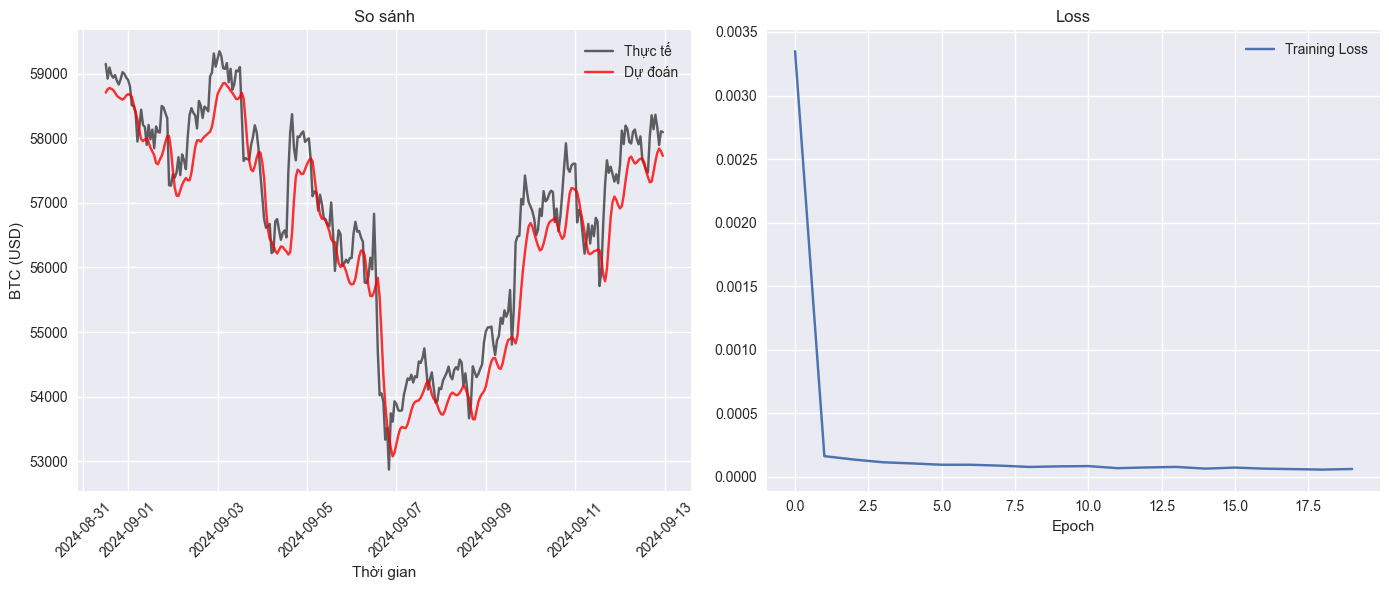

In [10]:
def train_and_evaluate():
    # 1. Config Model
    input_dim = 6 # open, high, low, close, volume, sentiment
    hidden_dim = 64
    num_layers = 2
    batch_size = 64
    epochs = 20 # Demo 20 epochs, bạn có thể tăng lên 50-100
    
    model = CryptoPredictor(input_dim, hidden_dim, num_layers, dropout=0.2).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # 2. DataLoader
    train_data = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    
    # 3. Training Loop
    print("\nBắt đầu huấn luyện...")
    loss_history = []
    
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for bx, by in train_loader:
            bx, by = bx.to(DEVICE), by.to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(bx)
            loss = criterion(outputs, by)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            
        avg_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_loss)
        if (epoch+1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}")
            
    # 4. Evaluation
    model.eval()
    with torch.no_grad():
        X_test_dev = X_test.to(DEVICE)
        predictions = model(X_test_dev).cpu().numpy()
        actuals = y_test.numpy()
        
    # Inverse Transform để về giá USD thật
    real_preds = scaler_y.inverse_transform(predictions)
    real_actuals = scaler_y.inverse_transform(actuals)
    
    # Tính RMSE
    rmse = math.sqrt(mean_squared_error(real_actuals, real_preds))
    print(f"\n=> RMSE trên tập Test: {rmse:.2f} USD")
    
    # 5. Vẽ biểu đồ
    plt.figure(figsize=(14, 6))
    
    # Biểu đồ giá
    plt.subplot(1, 2, 1)
    # Vẽ 300 điểm cuối cùng để nhìn cho rõ
    look_back = 300
    plt.plot(test_times[-look_back:], real_actuals[-look_back:], label='Thực tế', color='black', alpha=0.6)
    plt.plot(test_times[-look_back:], real_preds[-look_back:], label='Dự đoán', color='red', alpha=0.8)
    plt.title("So sánh")
    plt.xlabel("Thời gian")
    plt.ylabel("BTC (USD)")
    plt.legend()
    plt.xticks(rotation=45)
    
    # Biểu đồ Loss
    plt.subplot(1, 2, 2)
    plt.plot(loss_history, label='Training Loss')
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Chạy chương trình chính nếu dữ liệu đã sẵn sàng
if 'X_train' in locals():
    train_and_evaluate()